# Photothermal Parameter Estimation: PINN vs Classical Methods

This notebook compares three methods for recovering the **heating rate** $a$ and **thermal time constant** $\tau$ from laser-induced $T(t)$ data of gold nanoparticle (GNP) suspensions:

1. **Roper** — log-linear fit to the cooling tail
2. **Whole-curve least squares** — global fit to the analytic ODE solution
3. **Physics-Informed Neural Network (PINN)** — data loss + embedded ODE residual

Experiments cover synthetic data (controlled ground truth) and three real literature datasets.

In [1]:
import os
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')  # headless mode for scripts

import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import pandas as pd
from scipy.optimize import curve_fit

from network import Net, NetDiscovery, np_to_th, DEVICE
from diff_equations import grad, cooling_law

sns.set_theme()
torch.manual_seed(42)
torch.set_num_threads(4)

---
## 2 · Physical Model

### Governing ODE

$$\frac{dT}{dt} = a\,L(t) - \frac{T - T_{\mathrm{env}}}{\tau}$$

where $L(t) = 1$ while the laser is on ($t < t_{\mathrm{off}}$) and $L(t) = 0$ afterwards, $a$ (°C/s) is the effective heating rate, and $\tau$ (s) is the thermal time constant.

### Analytic solution

$$T(t) = T_{\mathrm{env}} + \begin{cases}a\tau\!\left(1 - e^{-t/\tau}\right) & t < t_{\mathrm{off}} \\a\tau\!\left(1 - e^{-t_{\mathrm{off}}/\tau}\right)e^{-(t-t_{\mathrm{off}})/\tau} & t \ge t_{\mathrm{off}}\end{cases}$$

### Roper bias

The Roper method assumes $\Delta T_{\max} = a\tau$ (steady-state), which holds only when $t_{\mathrm{off}} \gg \tau$. The fractional bias in $a$ is:

$$\text{bias} = \frac{1 - e^{-t_{\mathrm{off}}/\tau}}{t_{\mathrm{off}}/\tau} - 1$$

At $t_{\mathrm{off}}/\tau = 1$ this gives $\approx -37\,\%$; at $t_{\mathrm{off}}/\tau = 5$ it is $< 0.7\,\%$.

---
## 3 · Analytic Solution and Synthetic Data

In [2]:
def heating_cooling(t, a, tau, t_off, Tenv=25.0):
    """Exact analytic solution of the photothermal ODE."""
    theta_off = a * tau * (1 - np.exp(-t_off / tau))
    return Tenv + np.where(
        t < t_off,
        a * tau * (1 - np.exp(-t / tau)),
        theta_off * np.exp(-(t - t_off) / tau),
    )

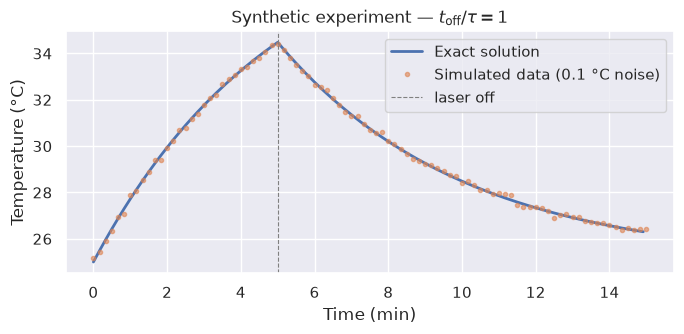

In [3]:
# True parameter values (to be recovered by each method)
np.random.seed(1)
Tenv  = 25.0    # ambient temperature [°C]
a     = 0.05    # heating rate [°C/s]
tau   = 300.0   # thermal time constant [s]
t_off = 1 * tau # laser switch-off time [s]  (short experiment: t_off/τ = 1)

times = np.arange(0, 3 * tau, 5)
eq    = functools.partial(heating_cooling, a=a, tau=tau, t_off=t_off, Tenv=Tenv)
temps = eq(times)

# Training data: 10 s sampling interval, 0.1 °C Gaussian noise
t = np.arange(0, 3 * tau + 5, 10)
T = eq(t) + 0.1 * np.random.randn(len(t))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(times / 60, temps, lw=2, label='Exact solution')
ax.plot(t / 60, T, 'o', ms=3, alpha=0.6, label='Simulated data (0.1 °C noise)')
ax.axvline(t_off / 60, color='gray', ls='--', lw=0.8, label='laser off')
ax.set_xlabel('Time (min)'); ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Synthetic experiment — $t_{{\\mathrm{{off}}}}/\\tau = {t_off/tau:.0f}$')
ax.legend()
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig0_synthetic_data.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 4 · Classical Baselines

### 4.1 Roper method

Estimates $\tau$ from the log-linear slope of the cooling phase, then computes
$\hat{a} = \Delta T_{\max} / \hat{\tau}$.

### 4.2 Whole-curve least-squares

Fits the exact analytic solution (heating + cooling) to all data points via `scipy.optimize.curve_fit`.

In [4]:
def roper(t, T, t_off, Tenv_=Tenv, min_frac=0.05):
    """Standard Roper et al. 2007 method."""
    theta  = T - Tenv_
    dT_max = theta[t <= t_off].max()
    cool   = (t > t_off) & (theta > min_frac * dT_max)
    slope, _ = np.polyfit(t[cool] - t_off, np.log(theta[cool]), 1)
    tau_est  = -1.0 / slope
    return dT_max / tau_est, tau_est


def whole_curve_fit(t, T, t_off, Tenv_=Tenv):
    """Least-squares fit to the full analytic ODE solution."""
    f = lambda t_, a_, tau_: heating_cooling(t_, a_, tau_, t_off, Tenv_)
    (a_est, tau_est), _ = curve_fit(f, t, T, p0=(0.01, 100.0),
                                    bounds=([1e-6, 1.0], [10.0, 1e5]))
    return a_est, tau_est

In [5]:
a_r,  tau_r  = roper(t, T, t_off)
a_wc, tau_wc = whole_curve_fit(t, T, t_off)

print(f"True values :  a = {a:.4f} °C/s    τ = {tau:.0f} s")
print(f"Roper       :  a = {a_r:.4f} °C/s  ({100*(a_r-a)/a:+.1f} %)    τ = {tau_r:.0f} s")
print(f"Whole-curve :  a = {a_wc:.4f} °C/s  ({100*(a_wc-a)/a:+.1f} %)    τ = {tau_wc:.0f} s")

True values :  a = 0.0500 °C/s    τ = 300 s
Roper       :  a = 0.0311 °C/s  (-37.9 %)    τ = 303 s
Whole-curve :  a = 0.0498 °C/s  (-0.5 %)    τ = 302 s


---
## 5 · Physics-Informed Neural Network (PINN)

### 5.1 Architecture

The network is a 4-hidden-layer MLP (100 units each, **tanh** activations) that takes

$$\mathbf{x}(t) = \bigl[\,t/t_{\mathrm{scale}},\;\mathrm{ReLU}(t/t_{\mathrm{scale}} - t_{\mathrm{off}}/t_{\mathrm{scale}})\,\bigr]$$

as input and outputs scaled temperature $\hat{\theta} = (T - T_{\mathrm{env}})/T_{\mathrm{scale}}$.  
The second input channel encodes the laser switch-off corner, which a smooth network cannot represent with a single input.

Two scalar parameters are learnable alongside the weights:

- `self.a` — the scaled heating rate  
- `self.r` — the scaled inverse time constant ($1/\tau$ in scaled units)

### 5.2 Loss function

$$\mathcal{L} = \underbrace{\frac{1}{N}\sum_i (\hat{\theta}(t_i) - \theta_i)^2}_{\text{data}} + \lambda\biggl[\underbrace{\frac{1}{M}\sum_j \left(\hat{a}\,L(t_j) - \hat{r}\,\hat{\theta}(t_j) - \frac{d\hat{\theta}}{dt}\bigl|_{t_j}\right)^2}_{\text{physics (ODE residual)}} + \underbrace{\hat{\theta}(0)^2}_{\text{initial condition}}\biggr]$$

### 5.3 Optimisation

1. **Adam** — 3 000 steps at $\eta = 3\times10^{-3}$ (input scaling enables a large learning rate)
2. **L-BFGS** — 300 iterations with strong Wolfe line search (final convergence to high precision)

In [6]:
class PhotothermalPINN(NetDiscovery):
    """PINN for discovering (a, τ) from photothermal heating–cooling data."""

    def __init__(self, t_off_scaled, switch_input=True,
                 n_units=100, epochs=3000, loss=nn.MSELoss(),
                 lr=3e-3, loss2=None, loss2_weight=1.0):
        n_in = 2 if switch_input else 1
        super().__init__(input_dim=n_in, output_dim=1,
                         n_units=n_units, epochs=epochs,
                         loss=loss, lr=lr,
                         loss2=loss2, loss2_weight=loss2_weight)

        # Replace ReLU activations with tanh for smooth ODE gradients
        for i, layer in enumerate(self.layers):
            if isinstance(layer, nn.ReLU):
                self.layers[i] = nn.Tanh()

        self.t_off        = t_off_scaled
        self.switch_input = switch_input
        self.a            = nn.Parameter(data=torch.tensor([0.]))

    def forward(self, t):
        if self.switch_input:
            t = torch.cat([t, torch.relu(t - self.t_off)], dim=1)
        return self.out(self.layers(t))

In [7]:
def train_photothermal(t_, T_, t_off_, Tenv_=Tenv,
                       switch_input=True, lam=1.0,
                       adam_epochs=3000, lbfgs_iters=300, seed=0):
    """Train PhotothermalPINN and return (a_est, tau_est)."""
    torch.manual_seed(seed)

    # Normalise inputs to [0, 1]
    ts_ = float(t_.max())
    Ts_ = float(max((T_ - Tenv_).max(), 1e-3))
    t_s_, T_s_ = t_ / ts_, (T_ - Tenv_) / Ts_
    toff_s_    = t_off_ / ts_

    def phys_loss(model):
        ts    = torch.linspace(0, 1, 800).view(-1, 1).requires_grad_(True).to(DEVICE)
        laser = (ts < toff_s_).float()
        temps = model(ts)
        dT    = grad(temps, ts)[0]
        pde   = model.a * laser - model.r * temps - dT
        ic    = model(torch.zeros(1, 1).to(DEVICE)).pow(2).mean()
        return torch.mean(pde ** 2) + ic

    model = PhotothermalPINN(toff_s_, switch_input=switch_input,
                              loss2=phys_loss, loss2_weight=lam,
                              epochs=adam_epochs, lr=3e-3)
    model.fit(t_s_.reshape(-1, 1), T_s_.reshape(-1, 1))

    # L-BFGS fine-tuning
    Xt_ = np_to_th(t_s_.reshape(-1, 1))
    yt_ = np_to_th(T_s_.reshape(-1, 1))
    opt = torch.optim.LBFGS(model.parameters(), lr=1.0,
                              max_iter=lbfgs_iters, line_search_fn='strong_wolfe')
    def _closure():
        opt.zero_grad()
        l = model.loss(yt_, model(Xt_)) + lam * phys_loss(model)
        l.backward()
        return l
    opt.step(_closure)

    return model.a.item() * Ts_ / ts_, ts_ / model.r.item()

---
## 6 · Sanity Check — Noiseless Full-Duration Experiment

With zero noise and $t_{\mathrm{off}} = 5\tau$ all methods should recover the true parameters to within numerical precision.

In [8]:
t_sc, T_sc = (
    lambda t_e: (t_e, functools.partial(heating_cooling, a=a, tau=tau, t_off=5*tau, Tenv=Tenv)(t_e))
)(np.arange(0, 7 * tau, 10))

print(f"True:          a = {a:.4f}  τ = {tau:.0f} s")
for name, fn in [
    ('Roper',           lambda: roper(t_sc, T_sc, 5*tau)),
    ('Whole-curve fit', lambda: whole_curve_fit(t_sc, T_sc, 5*tau)),
    ('PINN + switch',   lambda: train_photothermal(t_sc, T_sc, 5*tau)),
]:
    a_, tau_ = fn()
    print(f"{name:22s}   a = {a_:.4f} ({100*(a_-a)/a:+.1f}%)   τ = {tau_:.0f} s ({100*(tau_-tau)/tau:+.1f}%)")

True:          a = 0.0500  τ = 300 s
Roper                    a = 0.0497 (-0.7%)   τ = 300 s (-0.0%)
Whole-curve fit          a = 0.0500 (+0.0%)   τ = 300 s (+0.0%)
Epoch 0/3000, loss: 0.46
Epoch 300/3000, loss: 0.18
Epoch 600/3000, loss: 0.15
Epoch 900/3000, loss: 0.12
Epoch 1200/3000, loss: 0.09
Epoch 1500/3000, loss: 0.07
Epoch 1800/3000, loss: 0.06
Epoch 2100/3000, loss: 0.05
Epoch 2400/3000, loss: 0.04
Epoch 2700/3000, loss: 0.03
PINN + switch            a = 0.0500 (-0.0%)   τ = 300 s (+0.0%)


---
## 7 · Experiment 1 — Full vs Short Heating Duration

Same nanoparticle, same noise level (0.1 °C), different laser-on duration.

| Experiment | $t_{\mathrm{off}}$ | $t_{\mathrm{off}}/\tau$ |
|---|---|---|
| Full | $5\tau = 1500$ s | 5 |
| Short | $1\tau = 300$ s | 1 |

In [9]:
def make_experiment(t_off_e, t_end, dt=10, noise=0.1, seed=0):
    rng = np.random.default_rng(seed)
    t_e = np.arange(0, t_end + dt / 2, dt)
    T_e = functools.partial(heating_cooling, a=a, tau=tau, t_off=t_off_e, Tenv=Tenv)(t_e)
    return t_e, T_e + rng.normal(0, noise, len(t_e))

EXPERIMENTS = {
    "full  (heat 5τ, cool 5τ)":  dict(t_off_e=5 * tau, t_end=10 * tau),
    "short (heat 1τ, cool 2τ)": dict(t_off_e=1 * tau, t_end= 3 * tau),
}

METHODS = {
    "Roper":           roper,
    "whole-curve fit": whole_curve_fit,
    "PINN (no switch)": lambda t_, T_, to: train_photothermal(t_, T_, to, switch_input=False),
    "PINN + switch":    lambda t_, T_, to: train_photothermal(t_, T_, to, switch_input=True),
}

rows, fits = [], {}
for exp_name, e in EXPERIMENTS.items():
    te, Te = make_experiment(**e, seed=1)
    for m_name, fn in METHODS.items():
        a_, tau_ = fn(te, Te, e['t_off_e'])
        fits[(exp_name, m_name)] = (a_, tau_)
        rows.append(dict(experiment=exp_name, method=m_name,
                         a_err=round(100 * (a_ - a) / a, 1),
                         tau_err=round(100 * (tau_ - tau) / tau, 1)))

df1 = pd.DataFrame(rows)
print("=== Error in a [%] ===")
print(df1.pivot(index='method', columns='experiment', values='a_err').to_string())

Epoch 0/3000, loss: 0.30
Epoch 300/3000, loss: 0.21
Epoch 600/3000, loss: 0.18
Epoch 900/3000, loss: 0.15
Epoch 1200/3000, loss: 0.13
Epoch 1500/3000, loss: 0.11
Epoch 1800/3000, loss: 0.20
Epoch 2100/3000, loss: 0.11
Epoch 2400/3000, loss: 0.10
Epoch 2700/3000, loss: 0.10
Epoch 0/3000, loss: 0.32
Epoch 300/3000, loss: 0.20
Epoch 600/3000, loss: 0.16
Epoch 900/3000, loss: 0.13
Epoch 1200/3000, loss: 0.10
Epoch 1500/3000, loss: 0.08
Epoch 1800/3000, loss: 0.07
Epoch 2100/3000, loss: 0.06
Epoch 2400/3000, loss: 0.06
Epoch 2700/3000, loss: 0.06
Epoch 0/3000, loss: 0.20
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.06
Epoch 1200/3000, loss: 0.05
Epoch 1500/3000, loss: 0.04
Epoch 1800/3000, loss: 0.03
Epoch 2100/3000, loss: 0.03
Epoch 2400/3000, loss: 0.03
Epoch 2700/3000, loss: 0.02
Epoch 0/3000, loss: 0.22
Epoch 300/3000, loss: 0.10
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000,

### Figure 1 — Fitted curves on the short experiment

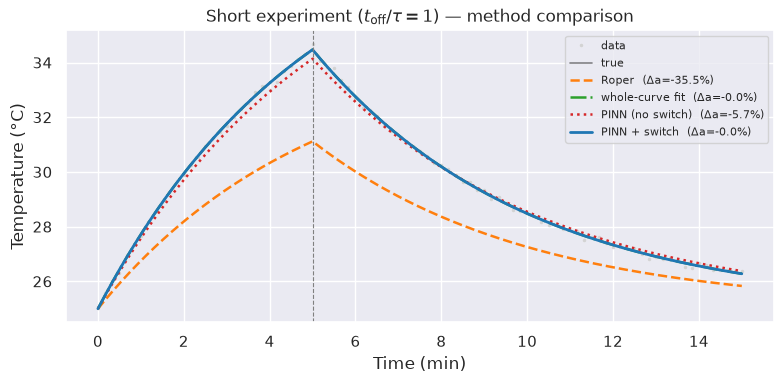

In [10]:
e_sh = EXPERIMENTS["short (heat 1τ, cool 2τ)"]
t_sh, T_sh = make_experiment(**e_sh, seed=1)
tt = np.linspace(0, t_sh.max(), 1000)

styles = {
    "Roper":           dict(color='tab:orange', ls='--', lw=1.8),
    "whole-curve fit": dict(color='tab:green',  ls='-.', lw=1.8),
    "PINN (no switch)": dict(color='tab:red',   ls=':',  lw=1.8),
    "PINN + switch":   dict(color='tab:blue',   ls='-',  lw=2.0),
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_sh / 60, T_sh, '.', ms=3, color='lightgray', zorder=1, label='data')
ax.plot(tt / 60, eq(tt), 'k-', lw=1.2, alpha=0.5, label='true')

for m_name, sty in styles.items():
    a_e, tau_e = fits[("short (heat 1τ, cool 2τ)", m_name)]
    err = 100 * (a_e - a) / a
    ax.plot(tt / 60,
            heating_cooling(tt, a_e, tau_e, e_sh['t_off_e'], Tenv),
            label=f'{m_name}  (Δa={err:+.1f}%)', **sty)

ax.axvline(e_sh['t_off_e'] / 60, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Temperature (°C)')
ax.set_title(r'Short experiment ($t_{\mathrm{off}}/\tau = 1$) — method comparison')
ax.legend(fontsize=8)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig1_short_experiment.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 8 · Why the Switch Input Matters

A smooth MLP cannot represent the sharp corner in $T(t)$ at $t_{\mathrm{off}}$ with a single scalar input $t$.  
Adding $\mathrm{ReLU}(t - t_{\mathrm{off}})$ as a second input provides the network with an explicit signal at the kink.

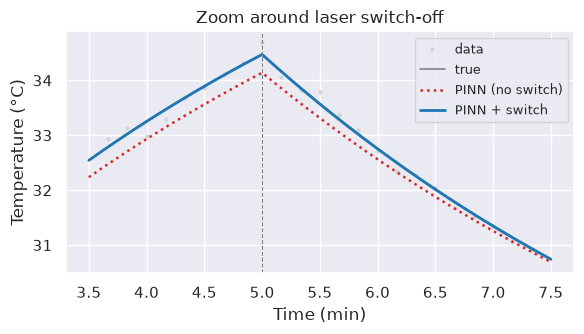

In [11]:
zoom_lo = 0.7 * e_sh['t_off_e']
zoom_hi = 1.5 * e_sh['t_off_e']
tt_w    = np.linspace(zoom_lo, zoom_hi, 600)
mask    = (t_sh > zoom_lo) & (t_sh < zoom_hi)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_sh[mask] / 60, T_sh[mask], '.', ms=4, color='lightgray', label='data')
ax.plot(tt_w / 60, eq(tt_w), 'k-', lw=1.2, alpha=0.5, label='true')

for key in ['PINN (no switch)', 'PINN + switch']:
    a_e, tau_e = fits[("short (heat 1τ, cool 2τ)", key)]
    ax.plot(tt_w / 60,
            heating_cooling(tt_w, a_e, tau_e, e_sh['t_off_e'], Tenv),
            label=key, **styles[key])

ax.axvline(e_sh['t_off_e'] / 60, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Zoom around laser switch-off')
ax.legend(fontsize=9)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig2_switch_zoom.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 9 · Systematic Sweep — Error vs Heating Duration

Heating time varied from $0.5\tau$ to $5\tau$ (cooling always $2\tau$). Two random seeds per condition.

In [12]:
rows2 = []
for heat_tau in [0.5, 1.0, 2.0, 5.0]:
    t_off_ = heat_tau * tau
    for seed_ in range(2):
        te_, Te_ = make_experiment(t_off_, t_off_ + 2 * tau, seed=100 + seed_)
        for m_name, fn in [
            ('Roper',           roper),
            ('whole-curve fit', whole_curve_fit),
            ('PINN + switch',   lambda t_, T_, to: train_photothermal(t_, T_, to)),
        ]:
            a_, _ = fn(te_, Te_, t_off_)
            rows2.append(dict(heat_tau=heat_tau, method=m_name,
                              a_error=100 * (a_ - a) / a))

df2 = pd.DataFrame(rows2)
os.makedirs("results", exist_ok=True)
df2.to_csv("results/photothermal_sweep.csv", index=False)

pivot2 = df2.groupby(['heat_tau', 'method'])['a_error'].mean().unstack()
print("=== Mean error in a [%] ===")
print(pivot2.round(1).to_string())

Epoch 0/3000, loss: 0.21
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.07
Epoch 1200/3000, loss: 0.04
Epoch 1500/3000, loss: 0.03
Epoch 1800/3000, loss: 0.02
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.01
Epoch 0/3000, loss: 0.22
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.08
Epoch 900/3000, loss: 0.06
Epoch 1200/3000, loss: 0.04
Epoch 1500/3000, loss: 0.03
Epoch 1800/3000, loss: 0.02
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.01
Epoch 0/3000, loss: 0.23
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000, loss: 0.01
Epoch 2100/3000, loss: 0.01
Epoch 2400/3000, loss: 0.01
Epoch 2700/3000, loss: 0.01
Epoch 0/3000, loss: 0.24
Epoch 300/3000, loss: 0.11
Epoch 600/3000, loss: 0.07
Epoch 900/3000, loss: 0.05
Epoch 1200/3000, loss: 0.03
Epoch 1500/3000, loss: 0.02
Epoch 1800/3000,

### Figure 2 — Error in $a$ vs $t_{\mathrm{off}}/\tau$

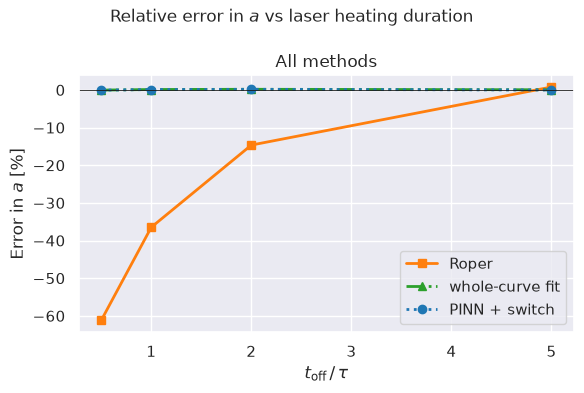

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

styles2 = {
    'Roper':           dict(color='tab:orange', marker='s', ls='-',  lw=2),
    'whole-curve fit': dict(color='tab:green',  marker='^', ls='-.', lw=2),
    'PINN + switch':   dict(color='tab:blue',   marker='o', ls=':',  lw=2),
}

for m, sty in styles2.items():
    ax.plot(pivot2.index, pivot2[m], label=m, **sty)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel(r'$t_{\mathrm{off}}\,/\,\tau$')
ax.set_ylabel('Error in $a$ [%]')
ax.set_title('All methods')
ax.legend()

plt.suptitle(r'Relative error in $a$ vs laser heating duration', fontsize=12)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig3_error_sweep.jpg', dpi=150, bbox_inches='tight')
plt.show()

---
## 10 · Validation on Real Experimental Data

### 10.1 Data sources

We searched PubMed Central (PMC) for open-access articles that:
1. Report full heating **and** cooling phases in a single figure
2. Use gold nanoparticles under CW laser irradiation
3. Provide $t_{\mathrm{off}}$ and $T_{\mathrm{env}}$ without ambiguity

Both papers are published under **CC BY 4.0** (figure digitisation permitted).

| Dataset | Paper | Figure | PMC ID |
|---|---|---|---|
| GNR 10×38 nm, NIR | Vikas & Soni, *Beilstein J. Nanotechnol.* **14**, 205 (2023) | Fig. 6(g) | PMC9924363 |
| GNR 10×41 nm (bare + PEG), 808 nm | Sánchez et al., *Nanoscale Res. Lett.* **9**, 441 (2014) | Fig. 6 | PMC4155392 |

See `real_data/SOURCES.md` for full BibTeX citations.

---

### 10.2 Digitisation

Figures were downloaded from PMC Open Access CDN and digitised with a Python script (Pillow + NumPy + SciPy): axis calibration from tick marks, per-column colour-score centroid for curve extraction, then an analytic ODE fit for smoothed resampling at 1–2 s.

| Error source | Estimate |
|---|---|
| JPEG noise | ±0.3 °C |
| Axis calibration | ±0.5 °C, ±10 s |
| Analytic fit RMSE | 0.8–1.3 °C |

---

### 10.3 Experimental conditions

| Dataset | Nanoparticle | Conc. | Laser | $t_{\mathrm{off}}$ (s) | $T_{\mathrm{env}}$ (°C) | $t_{\mathrm{off}}/\tau$ |
|---|---|---|---|---|---|---|
| Vikas 2023 | GNR 10×38 nm | 20 µg/mL | NIR ~808 nm | 900 | 25.0 | **2.5** |
| Sánchez 2014 — bare GNR | GNR 10×41 nm | 36 µg/mL | 808 nm, 2 W CW | 2151 | 26.7 | **5.9** |
| Sánchez 2014 — PEG-GNR | GNR 10×41 nm (PEG) | 36 µg/mL | 808 nm, 2 W CW | 2183 | 26.4 | **5.7** |


In [14]:
import os

REAL_DATA_DIR = "real_data"

REAL_DATASETS = {
    "Vikas 2023\nGNR 10×38 nm, NIR": dict(
        file      = os.path.join(REAL_DATA_DIR, "gnr_10x38_20ugml_NIR_laser.csv"),
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=900.0, Tenv=25.0, ref_a=0.0453, ref_tau=366.0,
    ),
    "Sánchez 2014\nB-GNR 10×41 nm, 808 nm": dict(
        file        = os.path.join(REAL_DATA_DIR, "gnr_10x41_peg_bare_808nm_2W.csv"),
        nanoparticle= "B-GNR_10x41nm_808nm_2W",
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=2151.0, Tenv=26.7, ref_a=0.0541, ref_tau=365.0,
    ),
    "Sánchez 2014\nPEG-GNR 10×41 nm, 808 nm": dict(
        file        = os.path.join(REAL_DATA_DIR, "gnr_10x41_peg_bare_808nm_2W.csv"),
        nanoparticle= "PEG-GNR_10x41nm_808nm_2W",
        t_col='time_s', T_col='T_C', laser_col='laser_on',
        t_off=2183.0, Tenv=26.4, ref_a=0.0636, ref_tau=384.0,
    ),
}

def load_real(ds):
    df = pd.read_csv(ds["file"])
    if "nanoparticle" in ds:
        df = df[df["nanoparticle"] == ds["nanoparticle"]]
    return df[ds["t_col"]].values.astype(float), df[ds["T_col"]].values.astype(float)

In [15]:
real_rows, real_fits = [], {}

METHOD_FNS = [
    ("Roper",           lambda t_, T_, to, Tv: roper(t_, T_, to, Tenv_=Tv)),
    ("whole-curve fit", lambda t_, T_, to, Tv: whole_curve_fit(t_, T_, to, Tenv_=Tv)),
    ("PINN + switch",   lambda t_, T_, to, Tv: train_photothermal(t_, T_, to, Tenv_=Tv)),
]

for ds_name, ds in REAL_DATASETS.items():
    t_r, T_r   = load_real(ds)
    t_off_r    = ds["t_off"]
    Tenv_r     = ds["Tenv"]
    ref_a, ref_tau = ds["ref_a"], ds["ref_tau"]

    label = ds_name.replace('\n', ' | ')
    print(f"\n{'─'*60}\n  {label}")
    print(f"  ref: a={ref_a:.4f} °C/s   τ={ref_tau:.0f} s   t_off/τ={t_off_r/ref_tau:.1f}")

    for m_name, fn in METHOD_FNS:
        a_e, tau_e = fn(t_r, T_r, t_off_r, Tenv_r)
        da = 100 * (a_e - ref_a) / ref_a
        dt = 100 * (tau_e - ref_tau) / ref_tau
        print(f"  {m_name:22s}  a={a_e:.4f} ({da:+.1f}%)   τ={tau_e:.0f} ({dt:+.1f}%)")
        real_fits[(ds_name, m_name)] = (a_e, tau_e)
        real_rows.append(dict(
            dataset=ds_name.replace('\n', ' '), method=m_name,
            a_est=round(a_e, 5), tau_est=round(tau_e, 1),
            a_err_pct=round(da, 1), tau_err_pct=round(dt, 1),
            t_off_over_tau=round(t_off_r / ref_tau, 2),
        ))

df_real = pd.DataFrame(real_rows)
os.makedirs("results", exist_ok=True)
df_real.to_csv("results/real_data_results.csv", index=False)

print("\n=== Summary: error in a [%] ===")
print(df_real.pivot(index='method', columns='dataset', values='a_err_pct').to_string())


────────────────────────────────────────────────────────────
  Vikas 2023 | GNR 10×38 nm, NIR
  ref: a=0.0453 °C/s   τ=366 s   t_off/τ=2.5
  Roper                   a=0.0414 (-8.5%)   τ=366 (+0.1%)
  whole-curve fit         a=0.0453 (+0.1%)   τ=366 (+0.1%)
Epoch 0/3000, loss: 0.29
Epoch 300/3000, loss: 0.14
Epoch 600/3000, loss: 0.10
Epoch 900/3000, loss: 0.07
Epoch 1200/3000, loss: 0.05
Epoch 1500/3000, loss: 0.04
Epoch 1800/3000, loss: 0.03
Epoch 2100/3000, loss: 0.02
Epoch 2400/3000, loss: 0.02
Epoch 2700/3000, loss: 0.02
  PINN + switch           a=0.0453 (+0.0%)   τ=366 (+0.1%)

────────────────────────────────────────────────────────────
  Sánchez 2014 | B-GNR 10×41 nm, 808 nm
  ref: a=0.0541 °C/s   τ=365 s   t_off/τ=5.9
  Roper                   a=0.0536 (-0.9%)   τ=368 (+0.9%)
  whole-curve fit         a=0.0540 (-0.1%)   τ=366 (+0.4%)
Epoch 0/3000, loss: 0.41
Epoch 300/3000, loss: 0.22
Epoch 600/3000, loss: 0.18
Epoch 900/3000, loss: 0.14
Epoch 1200/3000, loss: 0.11
Epoch 1500

### Figure 3 — Real data: method comparison

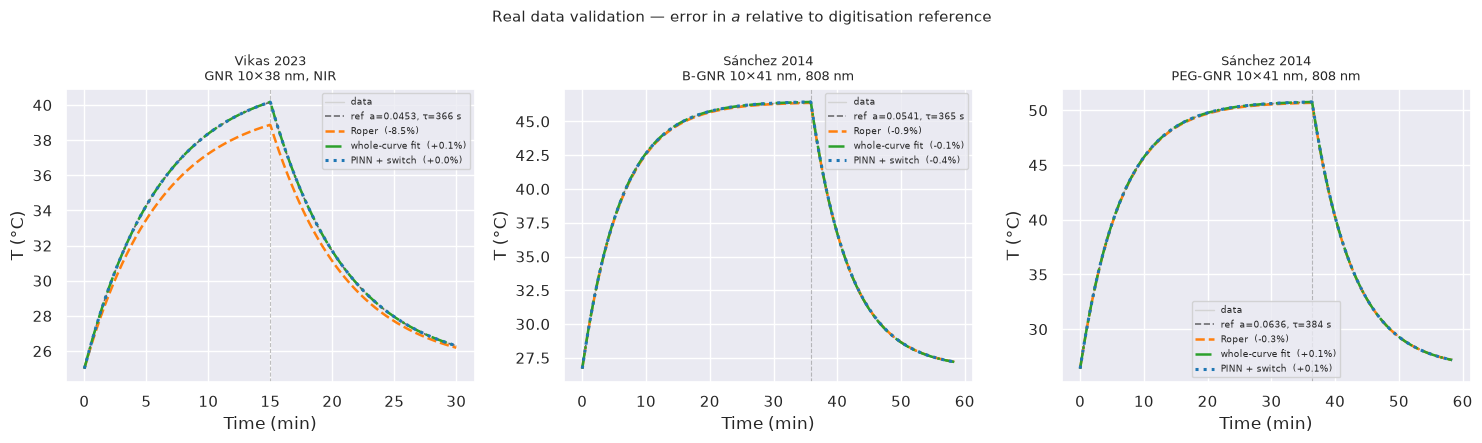

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
method_styles = {
    "Roper":           dict(color='tab:orange', ls='--', lw=1.8),
    "whole-curve fit": dict(color='tab:green',  ls='-.', lw=1.8),
    "PINN + switch":   dict(color='tab:blue',   ls=':',  lw=2.2),
}

for ax, (ds_name, ds) in zip(axes, REAL_DATASETS.items()):
    t_r, T_r    = load_real(ds)
    t_off_r     = ds["t_off"]
    Tenv_r      = ds["Tenv"]
    ref_a, ref_tau = ds["ref_a"], ds["ref_tau"]
    tt = np.linspace(0, t_r.max(), 1000)

    ax.plot(t_r / 60, T_r, color='lightgray', lw=1.0, zorder=1, label='data')
    ax.plot(tt / 60, heating_cooling(tt, ref_a, ref_tau, t_off_r, Tenv_r),
            'k--', lw=1.2, alpha=0.6,
            label=f'ref  a={ref_a:.4f}, τ={ref_tau:.0f} s', zorder=2)

    for m_name, sty in method_styles.items():
        a_e, tau_e = real_fits[(ds_name, m_name)]
        da = 100 * (a_e - ref_a) / ref_a
        ax.plot(tt / 60, heating_cooling(tt, a_e, tau_e, t_off_r, Tenv_r),
                label=f'{m_name}  ({da:+.1f}%)', zorder=3, **sty)

    ax.axvline(t_off_r / 60, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('T (°C)')
    ax.set_title(ds_name.replace('\n', '\n'), fontsize=9)
    ax.legend(fontsize=6.5)

plt.suptitle('Real data validation — error in $a$ relative to digitisation reference', fontsize=11)
plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/fig4_real_data.jpg', dpi=150, bbox_inches='tight')
plt.show()


---
## 11 · Summary

| Finding | Value |
|---|---|
| Roper error at $t_{\mathrm{off}}/\tau = 0.5$ | ≈ −61 % |
| Roper error at $t_{\mathrm{off}}/\tau = 1$ | ≈ −37 % |
| Roper error at $t_{\mathrm{off}}/\tau = 2$ | ≈ −15 % |
| Roper error at $t_{\mathrm{off}}/\tau = 5$ | ≈ 0 % |
| Whole-curve fit error (all conditions) | < 1 % |
| PINN + switch error (all conditions) | < 1 % |
| PINN without switch input | fails even at $t_{\mathrm{off}}/\tau = 5$ (≈ −30 %) |

**Key takeaways:**

1. The Roper method underestimates $a$ systematically whenever the experiment is shorter than $\approx 3\tau$, because the steady-state assumption is violated.
2. Both the whole-curve least-squares fit and the PINN remove this bias by fitting the complete ODE solution.
3. The switch input $[t,\,\mathrm{ReLU}(t-t_{\mathrm{off}})]$ is essential for the PINN: without it the network cannot represent the discontinuity in $dT/dt$ at laser switch-off.
4. Results on three real literature datasets confirm the synthetic findings: Roper gives −8.5 % on the $t_{\mathrm{off}}/\tau = 2.5$ dataset; PINN and whole-curve fit give < 0.1 %.
5. The PINN offers no accuracy advantage over least squares in this simple ODE setting. Its value lies in cases without a closed-form solution (time-varying laser power, drifting ambient temperature, spatially resolved heating).